In [8]:
import os
from pathlib import Path
from abc import ABC
from dataclasses import dataclass
from typing import List, Optional, Dict
from fogvis.db import Database
from contextlib import closing

DB_PATH : Path = Path(os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir, "media", "db")))
db = Database(DB_PATH)

In [9]:
@dataclass
class MarchedVisibility: 
    mean : float
    median : float 
    minimum : float
    num_rays : int

@dataclass
class ComplexVisibility:
    including_invalid_rays : Optional[MarchedVisibility] = None
    excluding_invalid_rays : Optional[MarchedVisibility] = None

@dataclass
class ImageVisibility: 
    vis_simple : Optional[float] = None
    vis_marched : Optional[ComplexVisibility] = None 

@dataclass
class RetreivedImageData:
    image_name : str
    vis_values : ImageVisibility

@dataclass
class FogImage:
    image_path: str
    visibility: float

@dataclass
class Dataset:
    images: List[FogImage]

class Experiment(ABC):
    def __init__(self, db: Database) -> None:
        self.db: Database = db

    def get_datasets(self) -> List[Dataset]:
        """Gathers a list of datasets to be used for training.
        Each item refers to a different set of data to be used in training a
        seperate instance of a model

        Returns:
            list: _description_
        """
        pass

class Basic_Synthetic_Quality(Experiment):
    def __init__(self, db: Database) -> None:
        super().__init__(db)

    @staticmethod
    def Get_Fog_Images(
        db: Database, fog_type_name: str, scene_name: str
    ) -> list[RetreivedImageData]:
        result: list[RetreivedImageData] = []
        
        with db as con:
            ctx = con.cursor()
            sql: str = """SELECT image.fileName, visibility_distance.distanceType, visibility_distance.value, visibility_distance.average, visibility_distance.median, visibility_distance.minimum, visibility_distance.rayCount FROM image
            INNER JOIN view ON view.colorImageID = image.id
            INNER JOIN camera ON view.cameraID = camera.id
            INNER JOIN scene ON view.sceneID = scene.id
            INNER JOIN environment ON view.environmentID = environment.id
            INNER JOIN fog ON environment.fogID = fog.id
            INNER JOIN fog_type ON fog.typeID = fog_type.id
            INNER JOIN visibility_distance ON visibility_distance.viewID = view.id
                WHERE fog_type.name = ? AND
                scene.name = ? 
            """
            parms = (fog_type_name, scene_name)
            ctx.execute(sql, parms)
            res = ctx.fetchall()
            if len(res) == 0:
                raise Exception("Failed to get images for scene")

            visibilities : Dict[str, ImageVisibility] = {}

            for r in res:
                name : str = r[0]
                mean : Optional[float] = None
                median : Optional[float] = None
                min : Optional[float] = None
                ray_count : Optional[int] = None

                if r[3] is not None: 
                    mean = float(r[3])
                if r[4] is not None: 
                    median = float(r[4])
                if r[5] is not None: 
                    min = float(r[5])
                if r[6] is not None: 
                    ray_count = int(r[6])

                if name not in visibilities: 
                    visibilities[name] = ImageVisibility(None, None)
                
                if r[1] == "simple": 
                    visibilities[name].vis_simple = float(r[2])
                elif r[1] == "ray_excluding_invalid": 
                    if mean is not None and median is not None and min is not None and ray_count is not None: 
                        if visibilities[name].vis_marched is None: 
                            visibilities[name].vis_marched = ComplexVisibility(excluding_invalid_rays = MarchedVisibility(mean=mean, median=median, minimum=min, num_rays=ray_count))
                        else:
                            visibilities[name].vis_marched.excluding_invalid_rays = MarchedVisibility(mean=mean, median=median, minimum=min, num_rays=ray_count)

                elif r[1] == "ray_including_invalid":
                    if (mean is not None and median is not None and min is not None and ray_count is not None): 
                        if visibilities[name].vis_marched is None:
                            visibilities[name].vis_marched = ComplexVisibility(including_invalid_rays = MarchedVisibility(mean=mean, median=median, minimum=min, num_rays=ray_count))
                        else:
                            visibilities[name].vis_marched.including_invalid_rays = MarchedVisibility(mean=mean, median=median, minimum=min, num_rays=ray_count)
                    else:
                        raise Exception(f"Failed to parse distance metrics for image. This should not happen.")

            for file_name in visibilities: 
                result.append(RetreivedImageData(image_name=file_name, vis_values=visibilities[file_name]))

        return result

    @staticmethod
    def Get_Linear_Dataset(db: Database) -> List[FogImage]:
        prepared_data : List[FogImage] = []
        for d in Basic_Synthetic_Quality.Get_Fog_Images(
                db, "linear", "berthoud_pass_co"
            ):
            prepared_data.append(FogImage(image_path=os.path.join(db.import_dir, d.image_name), visibility=float(d.vis_values.vis_simple)))
        return prepared_data

    @staticmethod
    def Get_Marched_Dataset(db: Database) -> list[FogImage]:
        prepared_data : list[FogImage] = []
        for d in Basic_Synthetic_Quality.Get_Fog_Images(db, "marched", "berthoud_pass_co"):
            path = os.path.join(db.import_dir, d.image_name)

            #only get the records with a excluding invalid rays
            if d.vis_values.vis_marched is not None and d.vis_values.vis_marched.excluding_invalid_rays is not None: 
                visibility = float(d.vis_values.vis_marched.excluding_invalid_rays.mean)
                prepared_data.append(FogImage(image_path=path,visibility=visibility))
        return prepared_data

    @staticmethod
    def Get_Exp_Dataset(db: Database) -> list[FogImage]:
        prepared_data : list[FogImage] = []
        for d in Basic_Synthetic_Quality.Get_Fog_Images(db, "exponential", "berthoud_pass_co"):
            path = os.path.join(db.import_dir, d.image_name)
            visibility = float(d.vis_values.vis_simple)
            prepared_data.append(FogImage(image_path=path, visibility=visibility))
        return prepared_data

    def get_datasets(self) -> List[Dataset]:
        result: List[Dataset] = [
            Dataset(images=self.Get_Linear_Dataset(self.db)),
            Dataset(images=self.Get_Exp_Dataset(self.db)),
            Dataset(images=self.Get_Marched_Dataset(self.db))
        ]
        return result
    
    def get_validation_dataset(self) -> Dataset: 
        return Dataset(images=self.Get_Marched_Dataset(self.db))

In [10]:
experiment : Basic_Synthetic_Quality = Basic_Synthetic_Quality(db)
datasets = experiment.get_datasets()
validation = experiment.get_validation_dataset()

## Demo Stuff
This code is just for showing what is in the dataset and making sure paths are correct

### Helpers

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import math
from collections import Counter

def display_image(img : FogImage) -> None: 
    i = mpimg.imread(img.image_path)
    plt.imshow(i)
    plt.axis('off')
    plt.title(f'Distance: {img.visibility} meters')
    plt.show()
    

def plot_visibility_classes(dataset):
    """
    Plot a bar graph showing the number of images in each visibility class.

    Each class is the floored number of miles of visibility.
    Example:
        0.3 miles -> class 0
        1.9 miles -> class 1
        5.0 miles -> class 5

    Parameters
    ----------
    dataset : Dataset
        A Dataset object containing a list of FogImage objects.
    """

    METERS_PER_MILE = 1609.344

    visibility_classes = []

    for image in dataset.images:
        try:
            vis_meters = float(image.visibility)
        except ValueError:
            print(f"Skipping invalid visibility value: {image.visibility}")
            continue

        vis_miles = vis_meters / METERS_PER_MILE
        vis_class = math.floor(vis_miles)

        visibility_classes.append(vis_class)

    class_counts = Counter(visibility_classes)

    if not class_counts:
        print("No valid visibility distances found.")
        return

    # Sort classes by visibility distance
    classes = sorted(class_counts.keys())
    counts = [class_counts[c] for c in classes]

    plt.figure(figsize=(10, 6))
    plt.bar(classes, counts)

    plt.xlabel("Visibility Class, Floored Miles")
    plt.ylabel("Number of Images")
    plt.title("Number of Fog Images by Visibility Distance")

    plt.xticks(classes)
    plt.grid(axis="y", alpha=0.3)

    plt.show()


### Datasets

Linear Images

In [12]:
lin = datasets[0]
exp = datasets[1]
marched = datasets[2]

In [13]:
print(f"Num Linear Images: {len(lin.images)}")
print(f"Num Exp Images: {len(exp.images)}")
print(f"Num Marched Images: {len(marched.images)}")

Num Linear Images: 14400
Num Exp Images: 14400
Num Marched Images: 2647


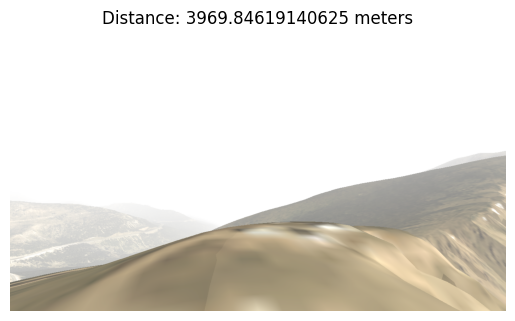

In [14]:
test_image : FogImage = random.choice(lin.images)
display_image(test_image)

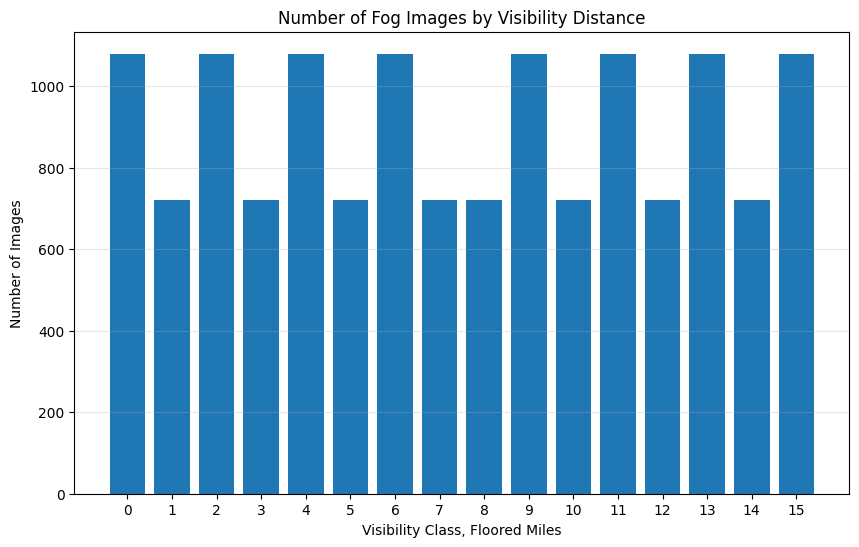

In [15]:
plot_visibility_classes(lin)

Exponential Images

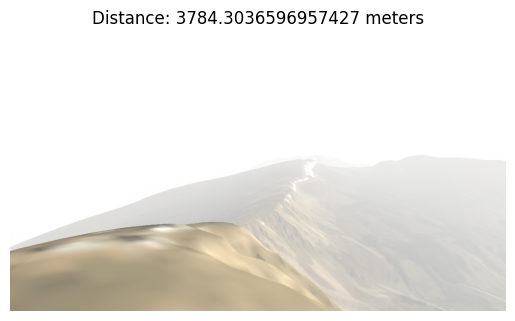

In [16]:
test_image : FogImage = random.choice(exp.images)
display_image(test_image)

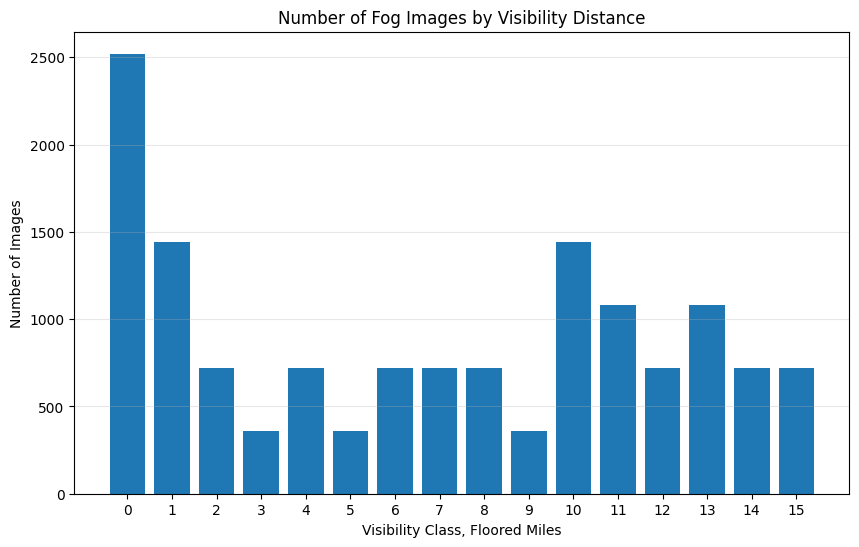

In [17]:
plot_visibility_classes(exp)

Marched

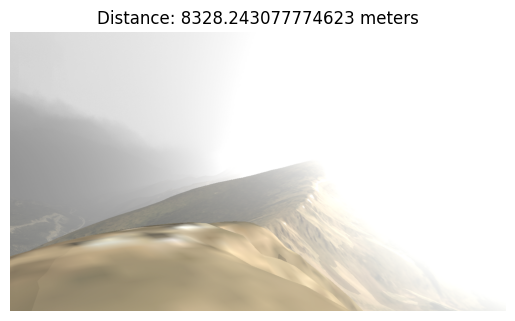

In [18]:
test_image : FogImage = random.choice(marched.images)
display_image(test_image)

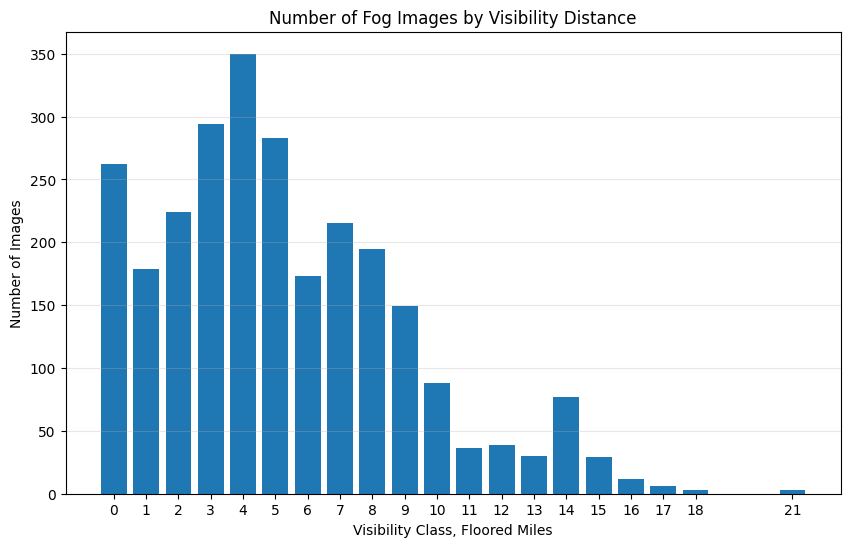

In [19]:
plot_visibility_classes(marched)